# Systems mapping for cowpea transpiration–soil water dynamics (FPP + SM)

**Paper:** Converging functional phenotyping with systems mapping to illuminate the genotype-phenotype associations. *Horticulture Research* (2024), DOI [10.1093/hr/uhae256](https://doi.org/10.1093/hr/uhae256), PMCID [PMC11630247](https://europepmc.org/articles/PMC11630247) (CC BY).

**Author code:** https://github.com/suntingsd/System-mapping — pinned commit `959b80c5b38002eeb50b5871f2fa173652c8279c`, `game_debug/` scripts (R; no license file — reuse terms unverified).

**Scope (partial demonstration):** Reproduce the paper's cowpea proof of concept — the two-equation ODE system for transpiration rate (TR) and volumetric soil water content (VWC) from the 32-genotype PlantArray FPP drought experiment (96 plants × 6 days). We execute the **authors' own R pipeline verbatim** (`debug.R` → `dat.RData`, then `test.R`: loess-smoothed Figure 1B analog and the Legendre/RK4 ODE fit behind Figure 2) and compare our outputs with the authors' committed reference PDFs.

**Out of scope:** the genome-wide SM step (24 SNPs, Table S1) — no association code or marker data exists in the repository.

**Execution status:** the notebook runs the author's R code through `/usr/bin/Rscript`; Python cells are launchers and visualization only. All data downloads and scientific execution happen inside this Colab VM.

**日本語:** 本ノートブックは、32遺伝子型の牛モヤシFPP乾燥実験データ（96株×6日）に対し、著者自身のRパイプライン（debug.R → dat.RData、test.R: loess平滑化Figure 1B相当、Legendre/RK4による2式ODEフィットFigure 2相当）をColab内のRscriptでそのまま実行します。Pythonセルは起動と可視化のみです。GWAS（Table S1）は対象外です。

## Runtime selection

**Select a CPU runtime** (Runtime → Change runtime type → CPU). This method is small linear algebra (loess, BFGS `optim`, RK4 on 2 equations) — no GPU is used or needed.

Expected duration: ~5 minutes total (downloads ≈ 5.7 MB, R execution ≈ 1–2 min).

**日本語:** ランタイムは **CPU** を選択してください。軽量な数値計算（loess、BFGS最適化、RK4）のみでGPUは不要です。所要時間は全体で約5分、ダウンロード約5.7 MBです。

The next cell verifies that `Rscript` (base R) is available, as the author pipeline is pure R.

In [ ]:
import shutil, subprocess
rscript = shutil.which("Rscript")
if rscript is None:
    raise RuntimeError("Rscript not found: this notebook requires the standard Colab R installation.")
print("Rscript:", rscript)
print(subprocess.run([rscript, "--version"], capture_output=True, text=True).stdout.strip())

Rscript: /usr/bin/Rscript
Rscript (R) version 4.6.1 (2026-06-24)


## Minimal input acquisition (Colab-only download)

We fetch only the files needed for the cowpea TR–VWC demonstration plus the authors' committed reference figures, from the **pinned commit** via `raw.githubusercontent.com`. Reference PDFs are saved under `ref_` names so they can never be confused with our own outputs.

| file | role | bytes | git blob SHA-1 |
|---|---|---|---|
| `game_debug/VWC.csv` | volumetric soil water content, 96 plants × 6 days | 5,572,226 | `d7e2a535…439c` |
| `game_debug/Transpiration.csv` | transpiration rate | 11,596 | `a2a0d936…83aba` |
| `game_debug/debug.R` | builds `dat.RData` from the CSVs | 512 | `d5cabd5f…348b` |
| `game_debug/test.R` | driver: loess fit + ODE fit + figures | 217 | `81e582ed…1984d7` |
| `game_debug/test_sup.R` | author functions (`ind_fit1`, `game_fit`, `game_plot`, …) | 12,690 | `7a1cb915…43650` |
| `game_debug/Figure1.pdf` → `ref_Figure1.pdf` | author reference output (comparison only) | 47,433 | `dbb28ce3…c6ea1` |
| `game_debug/Figure2.pdf` → `ref_Figure2.pdf` | author reference output (comparison only) | 46,355 | `9f23b99b…8fd9a9` |

The next cell downloads them, checks byte sizes, and verifies each file's **git blob SHA-1** against the pinned commit's tree (computed as `sha1("blob <len>\0" + bytes)`). A mismatch aborts before any science.

**日本語:** 著者リポジトリの固定コミットから、演示に必要なCSV・Rコード・参照PDFのみをダウンロードし、バイト数とgit blob SHA-1を検証します。不一致の場合は中断します。

In [ ]:
import hashlib, urllib.request

COMMIT = "959b80c5b38002eeb50b5871f2fa173652c8279c"
BASE = f"https://raw.githubusercontent.com/suntingsd/System-mapping/{COMMIT}/game_debug"
FILES = {
    "VWC.csv":           (5572226, "d7e2a5354786d0d915cc5ee4ba1b051104e1439c", "VWC.csv"),
    "Transpiration.csv": (  11596, "a2a0d93647ab30cb0c313be643b5b82057c83aba", "Transpiration.csv"),
    "debug.R":           (    512, "d5cabd5ff77a431a1dcf749b370891a3fd24348b", "debug.R"),
    "test.R":            (    217, "81e582ed56bd2358e7175fbe0a453eddcd1984d7", "test.R"),
    "test_sup.R":        (  12690, "7a1cb9157c0bf271b3f5bfb3d624f0e884493650", "test_sup.R"),
    "Figure1.pdf":       (  47433, "dbb28ce358a8e2fbb937021fba657d7c734c6ea1", "ref_Figure1.pdf"),
    "Figure2.pdf":       (  46355, "9f23b99be00394048403a3a826adfaa8082fd9a9", "ref_Figure2.pdf"),
}
for remote, (size, sha, local) in FILES.items():
    with urllib.request.urlopen(f"{BASE}/{remote}", timeout=120) as r:
        data = r.read()
    assert len(data) == size, f"{remote}: expected {size} bytes, got {len(data)}"
    blob = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    assert blob == sha, f"{remote}: blob SHA-1 mismatch ({blob})"
    with open(local, "wb") as f:
        f.write(data)
    print(f"OK  {remote:20s} -> {local:16s} {len(data):>9d} bytes  blob {blob[:12]}...")
print("All pinned files verified.")

OK  VWC.csv              -> VWC.csv            5572226 bytes  blob d7e2a5354786...


OK  Transpiration.csv    -> Transpiration.csv     11596 bytes  blob a2a0d93647ab...


OK  debug.R              -> debug.R                512 bytes  blob d5cabd5ff77a...


OK  test.R               -> test.R                 217 bytes  blob 81e582ed56bd...


OK  test_sup.R           -> test_sup.R           12690 bytes  blob 7a1cb9157c0b...


OK  Figure1.pdf          -> ref_Figure1.pdf      47433 bytes  blob dbb28ce358a8...


OK  Figure2.pdf          -> ref_Figure2.pdf      46355 bytes  blob 9f23b99be003...
All pinned files verified.


## Building `dat.RData` with the author's `debug.R`

`debug.R` reads the raw CSVs, aggregates per-measurement VWC rows into 6 daily means per plant, and saves the author's workspace object `dat.RData` (`vwc`, `Tran` matrices). One **documented adaptation**: the repository tree contains `VWC.csv` but `debug.R` reads `vwc.csv` (case-sensitive systems break). We copy `VWC.csv` to `vwc.csv` and otherwise run the author's script unmodified. `debug.R`'s raw `plot()` calls only write an unimportant `Rplots.pdf` under `Rscript`.

**日本語:** 著者の`debug.R`をそのまま実行し`dat.RData`を作成します。リポジトリの`VWC.csv`と`debug.R`の`vwc.csv`参照の大文字小文字不一致のみ、ファイル名コピーで回避します（文書化済みの唯一の適応）。

In [ ]:
import os, shutil, subprocess
shutil.copyfile("VWC.csv", "vwc.csv")   # case adaptation for debug.R's "vwc.csv" reference
r = subprocess.run(["Rscript", "debug.R"], capture_output=True, text=True, timeout=600)
print(r.stdout[-2000:]); print(r.stderr[-2000:])
if r.returncode != 0:
    # Known author off-by-one: debug.R's trailing plot loops index plants 1:97,
    # but the data hold 32 genotypes x 3 = 96 plants. The failure happens only
    # AFTER save(dat, "dat.RData"); accept the run only under that exact evidence.
    assert "subscript out of bounds" in r.stderr, r.stderr
    assert os.path.exists("dat.RData"), "dat.RData missing: debug.R failed before saving"
    print("debug.R finished data construction; its trailing plot loop hit the documented 1:97 off-by-one.")


Error in vwc[, i] : subscript out of bounds
Calls: lines -> lines.default -> plot.xy -> xy.coords
Execution halted

debug.R finished data construction; its trailing plot loop hit the documented 1:97 off-by-one.


### Verify the rebuilt data object

We check the reconstructed `dat.RData` has the dimensions the author pipeline expects — `vwc`: 6 days × 96 plants, `Tran`: 6 days × 96 plants — and export both matrices as CSV for the Python-side preview. Unexpected shapes abort the run.

**日本語:** 再構築した`dat.RData`の次元（vwc: 6日×96株、Tran: 6日×96株）を確認し、Python側プレビュー用にCSVへ書き出します。

In [ ]:
r_code = '''
load("dat.RData")
stopifnot(dim(dat$vwc) == c(6, 96), dim(dat$Tran) == c(6, 96))
write.csv(dat$vwc, "preview_vwc.csv", row.names = FALSE)
write.csv(dat$Tran, "preview_Tran.csv", row.names = FALSE)
cat("vwc:", dim(dat$vwc)[1], "days x", dim(dat$vwc)[2], "plants\n")
cat("Tran:", dim(dat$Tran)[1], "days x", dim(dat$Tran)[2], "plants\n")
cat("vwc range:", round(range(dat$vwc), 3), "  Tran range:", round(range(dat$Tran), 1), "\n")
'''
r = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True, timeout=300)
print(r.stdout); print(r.stderr)
r.check_returncode()

vwc: 6 days x 96 plants
Tran: 6 days x 96 plants
vwc range: 0.117 0.443   Tran range: 25.2 230.2 




## Input preview — 96 cowpea plants, 6 drought days

This is the actual reproduction input: per-plant VWC (top, cm³/cm³) and transpiration rate (bottom, g h⁻¹) over 6 days of water withholding, with the across-plant daily means (dark). VWC declines gradually; TR first rises slightly then declines from the fourth day — the two-phased drought response the paper's ODE system describes.

**日本語:** 再現対象の入力データ（96株のVWCと蒸散速度、6日間）を表示します。VWCは徐々に減少し、TRは4日目以降に減少へ転じる2相パターンを示します。

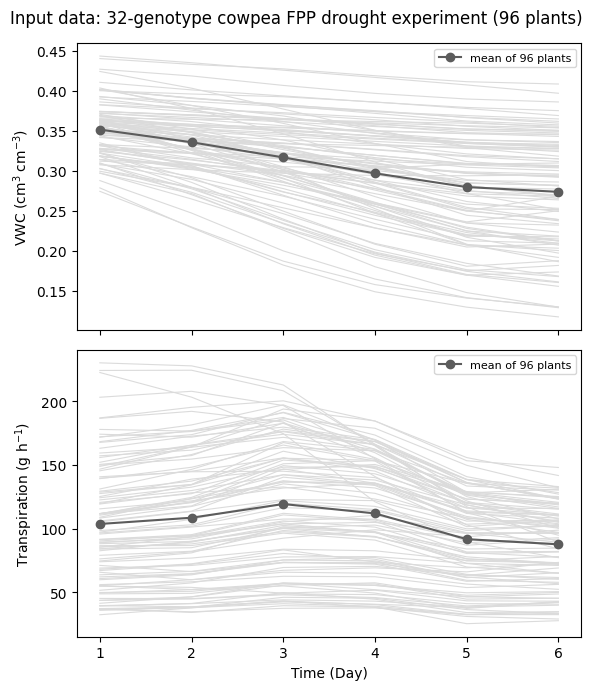

In [ ]:
import pandas as pd, matplotlib.pyplot as plt

vwc = pd.read_csv("preview_vwc.csv")        # rows: days, cols: plants
tr  = pd.read_csv("preview_Tran.csv")
days = range(1, 7)
fig, axes = plt.subplots(2, 1, figsize=(6, 7), sharex=True)
axes[0].plot(days, vwc.values, color="#DBDBDB", lw=0.8)
axes[0].plot(days, vwc.mean(axis=1).values, color="#5C5C5C", marker="o", label="mean of 96 plants")
axes[0].set_ylabel("VWC (cm$^3$ cm$^{-3}$)")
axes[1].plot(days, tr.values, color="#DBDBDB", lw=0.8)
axes[1].plot(days, tr.mean(axis=1).values, color="#5C5C5C", marker="o", label="mean of 96 plants")
axes[1].set_ylabel("Transpiration (g h$^{-1}$)")
axes[1].set_xlabel("Time (Day)")
for ax in axes:
    ax.legend(fontsize=8)
fig.suptitle("Input data: 32-genotype cowpea FPP drought experiment (96 plants)")
fig.tight_layout()
plt.show()

## Run the author pipeline: `test.R` (Figure 1B analog + ODE fit + Figure 2)

`test.R` is executed **unmodified**: it loads `dat.RData`, calls `ind_fit1` (loess span 0.7 smooth of the 96-plant means → `Figure1.pdf`, the paper's Figure 1B analog), then `game_fit` — Legendre polynomial (order 5) smoothing of mean VWC and log-TR on a 30-point grid, followed by the two-equation ODE fit (4th-order Runge–Kutta integration, BFGS `optim`) — and `game_plot` → `Figure2.pdf`. The `cat` lines below are the author's own per-equation fit diagnostics.

**日本語:** 著者の`test.R`を無修正で実行します。loess平滑化Figure1.pdf（論文Figure 1B相当）と、Legendre多項式平滑化＋RK4＋BFGSによる2式ODEフィットFigure2.pdfを作成します。

In [ ]:
r = subprocess.run(["Rscript", "test.R"], capture_output=True, text=True, timeout=1800)
print(r.stdout); print(r.stderr)
r.check_returncode()
import os
for f in ["Figure1.pdf", "Figure2.pdf"]:
    assert os.path.exists(f) and os.path.getsize(f) > 5000, f"{f} missing/too small"
print("Author pipeline completed: Figure1.pdf and Figure2.pdf produced.")

initial  value 0.072929 
iter  10 value 0.000000
iter  20 value 0.000000
iter  30 value 0.000000
iter  40 value 0.000000
iter  50 value 0.000000
iter  60 value 0.000000
iter  70 value 0.000000
iter  80 value 0.000000
iter  90 value 0.000000
iter 100 value 0.000000
iter 110 value 0.000000
iter 120 value 0.000000
iter 130 value 0.000000
iter 140 value 0.000000
iter 150 value 0.000000
iter 160 value 0.000000
iter 170 value 0.000000
iter 180 value 0.000000
iter 190 value 0.000000
iter 190 value 0.000000
final  value 0.000000 
converged
Gene= 1   2.279976e-10 
initial  value 0.333639 
iter  10 value 0.000005
iter  20 value 0.000000
final  value 0.000000 
converged
Gene= 2   8.892434e-08 
null device 
          1 

Loading required package: parallel

Author pipeline completed: Figure1.pdf and Figure2.pdf produced.


## Compare our `Figure1.pdf` with the author's committed reference

We render our newly generated `Figure1.pdf` next to the author's committed reference (clearly labeled), using `pypdfium2` for PDF→image rendering. Panel A: all 96 VWC curves with means and loess fit; panel B: transpiration. Agreement confirms the executed pipeline reproduces the published dynamics on this input.

**日本語:** 今回生成したFigure1.pdfと、固定コミットに含まれる著者の参照Figure1.pdf（ラベル明記）を並べて描画し一致を確認します。PDFの描画にはpypdfium2を使用します。

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 839.9 kB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━ 1.7/3.7 MB 9.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 14.6 MB/s eta 0:00:00


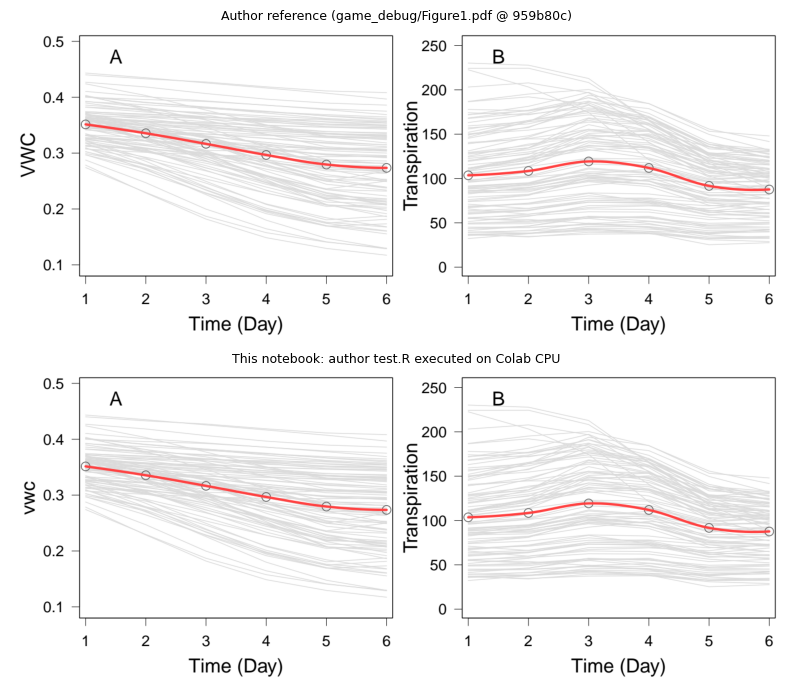

In [ ]:
%pip install -q pypdfium2
import pypdfium2 as pdfium
import matplotlib.pyplot as plt

def render(name, scale=2.0):
    return pdfium.PdfDocument(name)[0].render(scale=scale).to_pil()

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
for ax, (img, title) in zip(axes, [
    (render("ref_Figure1.pdf"), "Author reference (game_debug/Figure1.pdf @ 959b80c)"),
    (render("Figure1.pdf"),     "This notebook: author test.R executed on Colab CPU"),
]):
    ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis("off")
fig.tight_layout(); plt.show()

## Compare our `Figure2.pdf` (fitted ODE decomposition) with the author's reference

`game_plot` shows the fitted ODE components behind the paper's Figure 2: for VWC (A) and log-TR (B), the Legendre-smoothed mean curve (solid) plus the RK4-integrated independent and dependent ODE contributions (dashed/dotted). We again compare against the author's committed reference.

**日本語:** ODEフィット結果（VWCとlog-TRの独立項・従属項の寄与）を著者の参照Figure2.pdfと比較します。

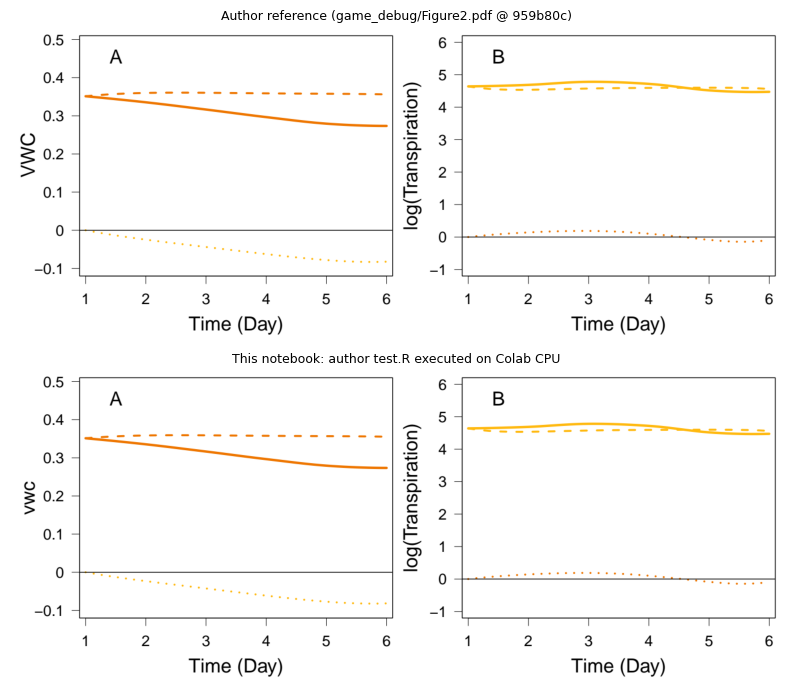

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7))
for ax, (img, title) in zip(axes, [
    (render("ref_Figure2.pdf"), "Author reference (game_debug/Figure2.pdf @ 959b80c)"),
    (render("Figure2.pdf"),     "This notebook: author test.R executed on Colab CPU"),
]):
    ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis("off")
fig.tight_layout(); plt.show()

## Fitted-curve summary table

We recompute the fit once more in a small R snippet in order to export the numerical results the figures only show graphically: the 30-point grids of the Legendre-smoothed mean VWC / log-TR and the RK4-solved ODE component curves (`odee`), written to `fit_summary.csv`. This is a diagnostic re-run of the same author functions (`test_sup.R`), not a modified method.

**日本語:** 図だけでは読み取れない数値結果を書き出すため、同じ著者関数をもう一度実行し、平滑化曲線とRK4のODE成分（30点グリッド）をCSVに保存して表示します。

In [ ]:
r_code = '''
load("dat.RData"); source("test_sup.R")
init.data <- ind_fit1(dat)
ode.fit  <- game_fit(dat = init.data)
grid <- seq(1, 6, length = 30)
out <- data.frame(day = grid,
                  vwc_smooth = init.data$msm.V[seq(1, 51, length = 30)],
                  logTR_smooth = log(init.data$msm.T[seq(1, 51, length = 30)]),
                  ode_vwc_ind  = ode.fit$odee[[1]][, 1],
                  ode_vwc_dep  = ode.fit$odee[[1]][, 2],
                  ode_logTR_ind = ode.fit$odee[[2]][, 1],
                  ode_logTR_dep = ode.fit$odee[[2]][, 2])
write.csv(out, "fit_summary.csv", row.names = FALSE)
cat("rows:", nrow(out), "\n")
'''
r = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True, timeout=1800)
print(r.stdout); print(r.stderr)
r.check_returncode()
import pandas as pd
df = pd.read_csv("fit_summary.csv")
df.head(30).round(4)

initial  value 0.072929 
iter  10 value 0.000000
iter  20 value 0.000000
iter  30 value 0.000000
iter  40 value 0.000000
iter  50 value 0.000000
iter  60 value 0.000000
iter  70 value 0.000000
iter  80 value 0.000000
iter  90 value 0.000000
iter 100 value 0.000000
iter 110 value 0.000000
iter 120 value 0.000000
iter 130 value 0.000000
iter 140 value 0.000000
iter 150 value 0.000000
iter 160 value 0.000000
iter 170 value 0.000000
iter 180 value 0.000000
iter 190 value 0.000000
iter 190 value 0.000000
final  value 0.000000 
converged
Gene= 1   2.279976e-10 
initial  value 0.333639 
iter  10 value 0.000005
iter  20 value 0.000000
final  value 0.000000 
converged
Gene= 2   8.892434e-08 
rows: 30 

Loading required package: parallel



,day,vwc_smooth,logTR_smooth,ode_vwc_ind,ode_vwc_dep,ode_logTR_ind,ode_logTR_dep
0,1.0000,103.5895,-1.0461,0.0000,0.0000,0.0000,0.0000
1,1.1724,103.8165,-1.0502,0.0021,-0.0047,-0.0463,0.0339
2,1.3448,104.4460,-1.0588,0.0038,-0.0090,-0.0769,0.0629
3,1.5172,105.3094,-1.0678,0.0052,-0.0130,-0.0952,0.0880
4,1.6897,105.8288,-1.0724,0.0062,-0.0169,-0.1042,0.1100
5,1.8621,107.0431,-1.0821,0.0069,-0.0205,-0.1065,0.1292
6,2.0345,108.4914,-1.0922,0.0075,-0.0240,-0.1041,0.1459
7,2.2069,110.5569,-1.1029,0.0078,-0.0274,-0.0988,0.1601
8,2.3793,111.8572,-1.1085,0.0080,-0.0307,-0.0918,0.1717
9,2.5517,114.6330,-1.1201,0.0080,-0.0340,-0.0842,0.1806


## Interpretation, limitations, and validation record

**What was reproduced (executed):** the author's own R pipeline on the committed 96-plant × 6-day cowpea input: loess-smoothed means (Figure 1B analog) and the two-equation Legendre/RK4 ODE system with its decomposition into independent and dependent contributions (Figure 2 analog). Our figures are compared side by side with the author's committed reference PDFs from the same pinned commit.

**What was NOT reproduced:** the genome-wide SM association of 24 SNPs (Table S1) — the repository contains no GWAS code or marker data; the paper's other examples are out of scope for this minimal demonstration.

**Adaptations (documented):** (1) `VWC.csv` copied to `vwc.csv` for the case-sensitive reference in `debug.R`; (2) Python is only a launcher — all numerics are the author's R code; (3) a diagnostic re-run of the same functions exports the fitted curves as CSV.

**Validation record:** this notebook was executed top to bottom in a fresh Colab CPU runtime; downloads and blob hashes were verified in-session. A single-example run is not verification of the paper's dataset-level claims. Repository has no README/license; terms of reuse are unverified.

**日本語:** 著者のRパイプラインそのものを実行し、Figure 1B相当とFigure 2相当（ODE独立項・従属項の分解）を再現し、著者の参照PDFと比較しました。GWAS（Table S1）は未再現です。適応は3点のみ（vwc.csvのケース修正、Pythonは起動のみ、CSV書き出し用の診断的再実行）。リポジトリにREADME/ライセンスがないため再利用条件は未確認です。

**References:** paper DOI 10.1093/hr/uhae256 · code `suntingsd/System-mapping@959b80c5b38002eeb50b5871f2fa173652c8279c` · data `game_debug/VWC.csv`, `game_debug/Transpiration.csv`.

In [ ]:
import shutil
shutil.copyfile("fit_summary.csv", "cowpea_TR_VWC_ode_fit_summary.csv")
print("Exported cowpea_TR_VWC_ode_fit_summary.csv (%d rows)" % len(df))

Exported cowpea_TR_VWC_ode_fit_summary.csv (30 rows)
